# FSI → multi-coil 4D Flow MRI · Case 0141 · SPGR

This notebook uses the moving FSI geometry from VMR **`0141_H_CORO_KD`** and generates **SPGR** k-space with four encodings: `[reference, vz, vy, vx]`.
Edit the configuration and run all cells. By default, all **20 native CFD frames** are retained at **30.8735 ms** spacing.
The geometry view uses volume streamlines; later cells display the synthetic B0 map, orthogonal k-space/image planes, and phase-derived velocity.

In [12]:
from pathlib import Path
import json, time, warnings
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d.art3d import Line3DCollection, Poly3DCollection
from IPython.display import display, HTML
import vtk
from vtk.util.numpy_support import numpy_to_vtk, vtk_to_numpy
from scipy.spatial import cKDTree
from src.flowphantom import *
from src.flowphantom.temporal import native_frame_indices

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'pyproject.toml').exists())
DATA = ROOT / 'data' / '0141_H_CORO_KD'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.labelsize': 10, 'axes.titlesize': 11, 'font.size': 10})
print('Repository:', ROOT)

Repository: /nas-data/ryy_rawdata/gitrepo/4DFlowPhantom


## 1 · Files and configuration

| File | Use |
|---|---|
| `results/fsi/KDR32_FSI.vtu` | Volume mesh, 20 velocity arrays, and matching displacement arrays; required for the phantom and volume streamlines |
| `Simulations/FSI_ptsE_cor115/varwallprop.vtp` | Matching wall with local `thickness`; required for the configured wall signal |
| `Simulations/FSI_ptsE_cor115/FSI_ptsE_cor115/solver.inp` | Source of `Time Step Size: 0.00061747`; not opened when timing is explicit |
| `results/fsi/KDR32_FSI.vtp` | Optional downloaded surface results: pressure, velocity, displacement, WSS/OSI; used for the geometry surface view |

`project=None` uses explicit files. Adjacent array suffixes differ by 50 solver steps, so native spacing is `50 × 0.00061747 s = 30.8735 ms`.
`times_s`, if supplied, overrides `time_step_s` and provides one physical timestamp per sorted velocity array.
`period_s=None` assumes a complete periodic cycle without a duplicate endpoint: **0.61747 s** here.

- `frames=None`: retain original timestamps and all native frames. An integer requests that many uniformly spaced frames over the same cycle; native frames are selected directly whenever they match, otherwise a warning precedes interpolation.
- `interpolation_order`: **0 nearest, 1 linear, 2 quadratic, 3 cubic**. Velocity and displacement use the same method, with periodic boundaries when enabled. Wall velocity is the displacement derivative; nearest interpolation gives zero wall velocity between jumps. Higher orders may overshoot.
- Source units are `cm` and `cm/s`; output lengths use mm, sequence/tissue times use ms, and VENC uses cm/s. Resolution and VENC entries follow z/y/x order; other spatial vectors (B0 coefficients, FOV, centre, coil centres) follow x/y/z.
- `WALL_THICKNESS_MM=None` reads VTP thickness; a number supplies a constant override in mm.
- `venc_cm_s` is a flat z/y/x list, repeated for multi-VENC; `[150,150,150,30,30,30]` gives seven channels including the shared reference.

In [13]:
INPUT = {
    'cfd': str(DATA / 'results' / 'fsi' / 'KDR32_FSI.vtu'),
    'project': None,
    'length_unit': 'cm',
    'velocity_unit': 'cm/s',
    'time_step_s': 0.00061747,
    'times_s': None,
    'period_s': None,
    'periodic': True,
    'wall_surface': str(DATA / 'Simulations' / 'FSI_ptsE_cor115' / 'varwallprop.vtp'),
    'velocity_prefix': 'velocity_',
    'displacement_prefix': 'displacement_',
}
SURFACE_RESULTS = DATA / 'results' / 'fsi' / 'KDR32_FSI.vtp'  # optional surface view

BLOOD = {'T1_ms': 1600.0, 'T2_ms': 200.0, 'PD': 1.0,
         'T2star_ms': 80.0, 'off_resonance_hz': 0.0}
WALL = {'T1_ms': 1000.0, 'T2_ms': 50.0, 'PD': 0.7,
        'T2star_ms': 30.0, 'off_resonance_hz': 0.0}
BACKGROUND_ENABLED = False
BACKGROUND = {'T1_ms': 1000.0, 'T2_ms': 80.0, 'PD': 0.2,
              'T2star_ms': 40.0, 'off_resonance_hz': 0.0}
WALL_THICKNESS_MM = None

B0 = {
    'offset_hz': 0.0,                              # Uniform frequency offset in Hz
    'gradient_hz_per_mm': (0.15, -0.10, 0.05),       # Linear shim residual in Hz/mm, x/y/z
    'quadratic_hz_per_mm2': (0.0, 0.0, 0.0),         # Quadratic shim residual in Hz/mm^2, x/y/z
    'smooth_std_hz': 100.0,                         # Nominal standard deviation of the smooth spatial residual in Hz; 0 disables it
    'correlation_length_mm': (15.0, 20.0, 25.0),     # Spatial correlation lengths in mm, x/y/z; larger values give smoother variation
    'seed': 0,                                    # Reproducible static B0 realization, independent of the acquisition noise seed
}
SEQUENCE = {'model': 'spgr', 'TR_ms': 5.0, 'TE_ms': 2.5, 'flip_deg': 15.0,
            'rf_phase_increment_deg': 180.0, 'off_resonance_hz': 0.0}
COILS = {'count': 5, 'layout': 'cylinder', 'rings': 2,
         'radius_mm': None, 'axial_span_mm': None, 'sensitivity_width_mm': None,
         'centers_mm': None, 'phase_scale': 0.5}
ACQUISITION = {
    'resolution_mm': [2.5, 2.5, 2.5],  # Output voxel size [dz, dy, dx] in mm
    'frames': None,                   # Output frame count; None keeps native frames; select directly when possible, otherwise warn and interpolate
    'interpolation_order': 1,         # Temporal interpolation of velocity/displacement: 0 nearest, 1 linear, 2 quadratic, 3 cubic
    'venc_cm_s': [150.0, 150.0, 150.0], # VENC values in cm/s, cycling through z/y/x; one shared reference encoding is added
    'padding_mm': 5.0,                # Extra space on each side of the moving geometry bounds for automatic FOV, in mm
    'fov_mm': None,                   # FOV size [x, y, z] in mm; None uses moving geometry bounds and padding
    'center_mm': None,                # FOV center [x, y, z] in phantom-centered mm; None uses the moving bounding-box center
    'b0': B0Field(**B0),              # Static B0 off-resonance field configured above; None disables this field
    'subvoxels': 2,                   # Subdivisions per voxel axis; 2 gives 2x2x2 samples for complex-signal integration and tissue fractions
    'temporal_samples': 1,            # Samples per frame window: 1 uses its center; >1 averages complex signals across the window; frame count is unchanged
    'snr': 20.0,                      # Ideal pure-blood magnitude / noise std per real or imaginary component; linear ratio, not dB; None disables noise
    'seed': 0,                        # Gaussian-noise random seed; identical parameters and seed reproduce the noise
    'device': select_device('auto'),  # Use available CuPy/Warp CUDA, otherwise CPU; explicit choices include 'cpu' and 'cuda:0'
}

OUTPUT_DIR = ROOT / 'outputs' / 'case0141_demo'
OUTPUT = None  # optional: OUTPUT_DIR / 'fsi_spgr.h5'; None returns arrays
SHOW_PROGRESS = True
SAVE_FIGURES = True
VIS_FRAME_INDEX = 5
VIS_COIL_INDEX = 0          # the displayed k-space belongs to this receive coil
VIS_PHASE_MIN_SNR = 5.0     # Mask phase below this estimated SNR in the complex combined image
VIS_SLICE_XYZ = None        # optional (ix, iy, iz); None selects planes with most blood
STREAMLINE_SEEDS = 200
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, name):
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / f'{name}.png', dpi=140, bbox_inches='tight', facecolor='white')
print('Compute device:', ACQUISITION['device'])

Compute device: cuda:0


## 2 · Native timestamps and requested frame count

The table shows whether each count can select native frames directly. This decision uses physical timestamps, including for nonuniform data.
A periodic request excludes the duplicated cycle endpoint; a nonperiodic request includes both endpoints.

In [14]:
SOURCE = CFDInput(**INPUT)
INFO = inspect_case(SOURCE)
if not INFO['deformable']:
    raise ValueError('This notebook requires matching FSI displacement arrays.')
PLANNED_TIMES, _ = make_time_axis(INFO, ACQUISITION['frames'], ACQUISITION['interpolation_order'])
examples = [None, 10, 5, 7, 30]
rows = []
for count in examples:
    with warnings.catch_warnings(record=True):
        times, messages = make_time_axis(INFO, count, ACQUISITION['interpolation_order'])
    selected = native_frame_indices(INFO['times_s'], times)
    method = 'native' if count is None else 'direct selection' if selected is not None else 'interpolation'
    spacing = f'{np.diff(times)[0]*1000:.4f}' if len(times) > 1 else '—'
    rows.append(f'<tr><td>{count}</td><td>{len(times)}</td><td>{spacing}</td><td>{method}</td></tr>')
display(HTML('<table><tr><th>frames</th><th>Output frames</th><th>Spacing [ms]</th>'
             '<th>Sampling</th></tr>' + ''.join(rows) + '</table>'))
print('Native frames:', INFO['n_frames'], '| native interval [ms]:', INFO['native_dt_ms'])
print('Requested timestamps [ms]:', np.round(PLANNED_TIMES*1000, 4))

frames,Output frames,Spacing [ms],Sampling
None,20,30.8735,native
10,10,61.7470,direct selection
5,5,123.4940,direct selection
7,7,88.2100,interpolation
30,30,20.5823,interpolation


Native frames: 20 | native interval [ms]: 30.873499999999776
Requested timestamps [ms]: [  0.      30.8735  61.747   92.6205 123.494  154.3675 185.241  216.1145
 246.988  277.8615 308.735  339.6085 370.482  401.3555 432.229  463.1025
 493.976  524.8495 555.723  586.5965]


## 3 · FSI geometry and volume streamlines

Streamlines follow the **instantaneous volume velocity field**, on `reference_points + displacement(t)`. They are not particle pathlines over the cardiac cycle.
The optional results VTP supplies the displayed surface; its surface-only velocity cannot replace the VTU volume field. The simulation still uses `varwallprop.vtp` for positive wall thickness.

FSI loaded in 1.51 s; wall thickness [mm]: [0.2163042426109314, 1.34658682346344]
Results VTP: 41243 surface nodes; 20 velocity frames; WSS available: True


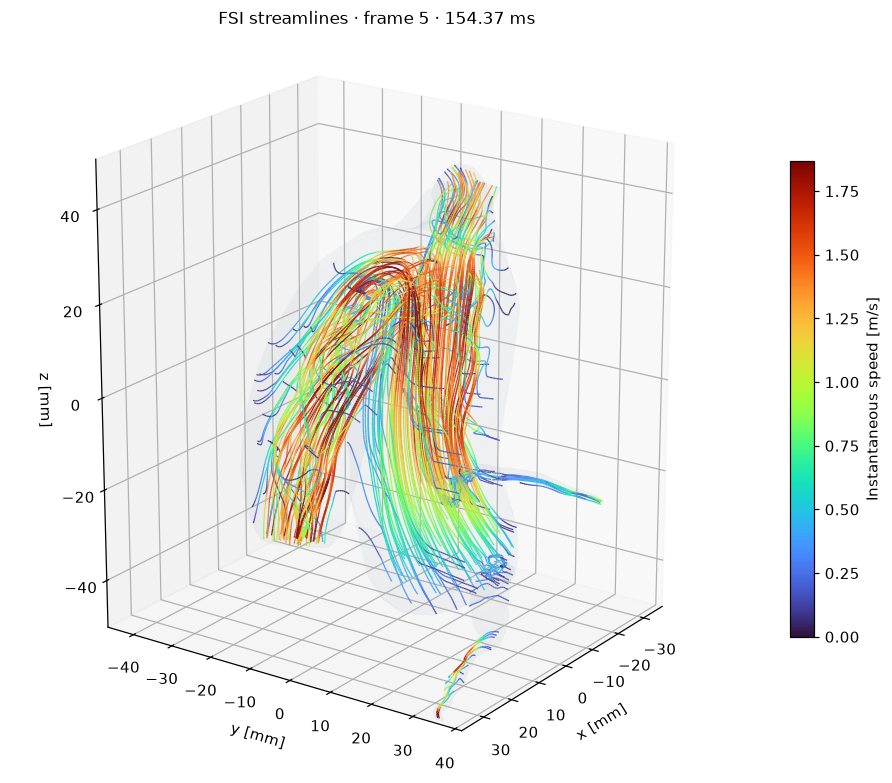

Traced streamlines: 395


In [15]:
start = time.perf_counter()
case = load_case(SOURCE)
if case.wall is None:
    raise ValueError('Supply the matching wall VTP.')
print('FSI loaded in', round(time.perf_counter()-start, 2), 's; wall thickness [mm]:',
      case.info['wall_thickness_range_mm'])
geometry_frame = min(VIS_FRAME_INDEX, len(PLANNED_TIMES)-1)
geometry_time = float(PLANNED_TIMES[geometry_frame])
mesh, moving_wall, _ = case.fields(geometry_time, ACQUISITION['interpolation_order'])
mesh.GetPointData().SetActiveVectors('velocity_m_s')
points = vtk_to_numpy(mesh.GetPoints().GetData())
velocity = vtk_to_numpy(mesh.GetPointData().GetArray('velocity_m_s'))
speed = np.linalg.norm(velocity, axis=1)

surface = moving_wall
if SURFACE_RESULTS.is_file():
    reader = vtk.vtkXMLPolyDataReader()
    reader.SetFileName(str(SURFACE_RESULTS))
    reader.UpdateInformation()
    fields = reader.GetPointDataArraySelection()
    field_names = [fields.GetArrayName(i) for i in range(fields.GetNumberOfArrays())]
    fields.DisableAllArrays()
    reader.GetCellDataArraySelection().DisableAllArrays()
    reader.Update()
    surface = vtk.vtkPolyData()
    surface.ShallowCopy(reader.GetOutput())
    scale = {'m': 1000.0, 'cm': 10.0, 'mm': 1.0}[INPUT['length_unit']]
    reference_surface = vtk_to_numpy(surface.GetPoints().GetData())*scale-case.world_center_mm
    distance, mapping = cKDTree(case.reference_points_mm).query(reference_surface)
    if distance.max() > 0.01:
        raise ValueError('Surface results do not match the volume reference mesh.')
    moved = vtk.vtkPoints()
    moved.SetData(numpy_to_vtk(np.ascontiguousarray(points[mapping]), deep=True))
    surface.SetPoints(moved)
    print('Results VTP:', surface.GetNumberOfPoints(), 'surface nodes;',
          sum(n.startswith('velocity_') for n in field_names), 'velocity frames;',
          'WSS available:', 'vTAWSS' in field_names)
else:
    print('Surface results VTP not present; displaying the configured wall surface.')

interior = np.ones(len(points), dtype=bool)
interior[case.wall_point_indices] = False
candidates = np.flatnonzero(interior & (speed > np.percentile(speed[interior], 40)))
selected = np.random.default_rng(42).choice(candidates, size=min(STREAMLINE_SEEDS, len(candidates)), replace=False)
seed_points = vtk.vtkPoints()
seed_points.SetData(numpy_to_vtk(np.ascontiguousarray(points[selected]), deep=True))
seeds = vtk.vtkPolyData(); seeds.SetPoints(seed_points)
tracer = vtk.vtkStreamTracer()
tracer.SetInputData(mesh); tracer.SetSourceData(seeds)
tracer.SetIntegratorTypeToRungeKutta4(); tracer.SetIntegrationDirectionToBoth()
tracer.SetMaximumPropagation(250.0)
tracer.SetIntegrationStepUnit(vtk.vtkStreamTracer.LENGTH_UNIT)
tracer.SetInitialIntegrationStep(0.5)
tracer.SetComputeVorticity(False)
tracer.Update()
streams = tracer.GetOutput()
if streams.GetNumberOfLines() == 0:
    raise ValueError('No streamlines were traced; adjust frame or seed selection.')
stream_points = vtk_to_numpy(streams.GetPoints().GetData())
stream_speed = np.linalg.norm(vtk_to_numpy(streams.GetPointData().GetArray('velocity_m_s')), axis=1)
segments, colours = [], []
lines = streams.GetLines(); lines.InitTraversal(); ids = vtk.vtkIdList()
while lines.GetNextCell(ids):
    nodes = np.array([ids.GetId(i) for i in range(ids.GetNumberOfIds())])
    segments.extend(np.stack([stream_points[nodes[:-1]], stream_points[nodes[1:]]], axis=1))
    colours.extend((stream_speed[nodes[:-1]] + stream_speed[nodes[1:]])/2)

triangulate = vtk.vtkTriangleFilter(); triangulate.SetInputData(surface); triangulate.Update()
decimate = vtk.vtkDecimatePro(); decimate.SetInputConnection(triangulate.GetOutputPort())
decimate.SetTargetReduction(0.93); decimate.PreserveTopologyOn(); decimate.Update()
outline = decimate.GetOutput()
faces = vtk_to_numpy(outline.GetPolys().GetConnectivityArray()).reshape(-1, 3)
triangles = vtk_to_numpy(outline.GetPoints().GetData())[faces]
fig = plt.figure(figsize=(10, 7), layout='constrained')
ax = fig.add_subplot(projection='3d')
ax.add_collection3d(Poly3DCollection(triangles, facecolor='#AAB9C5', edgecolor='none', alpha=0.06))
stream_artist = Line3DCollection(segments, cmap='turbo', norm=Normalize(0, np.percentile(speed, 99)), linewidth=0.8)
stream_artist.set_array(np.asarray(colours))
ax.add_collection3d(stream_artist)
lo, hi = points.min(axis=0), points.max(axis=0)
ax.set(xlim=(lo[0],hi[0]), ylim=(lo[1],hi[1]), zlim=(lo[2],hi[2]),
       xlabel='x [mm]', ylabel='y [mm]', zlabel='z [mm]',
       title=f'FSI streamlines · frame {geometry_frame} · {geometry_time*1000:.2f} ms')
ax.set_box_aspect(hi-lo); ax.view_init(elev=20, azim=35)
fig.colorbar(stream_artist, ax=ax, shrink=0.65, label='Instantaneous speed [m/s]')
save_figure(fig, '01_fsi_streamlines')
plt.show()
print('Traced streamlines:', streams.GetNumberOfLines())

## 4 · Generate SPGR multi-coil k-space

Complex blood, wall, and optional background signal is multiplied by receive sensitivities before Fourier cropping.
VENC applies to **each velocity component**, not total speed. Encoding uses `exp(i π v/VENC)` with the original velocity, so exceeding VENC causes real phase wrapping. A warning reports exceedances; velocities are not clipped or unwrapped.

In [16]:
if 'RESULT' in globals():
    RESULT.close()
output = OUTPUT
start = time.perf_counter()
callback = (lambda done, total: print(f'frame {done}/{total}', flush=True)) if SHOW_PROGRESS else None
RESULT = simulate(case, blood=Tissue(**BLOOD), wall=Tissue(**WALL),
                  background=Tissue(**BACKGROUND) if BACKGROUND_ENABLED else None,
                  sequence=Sequence(**SEQUENCE), coils=CoilArray(**COILS),
                  wall_thickness_mm=WALL_THICKNESS_MM, output=output,
                  progress=callback, **ACQUISITION)
result = RESULT
summary = {'sequence': 'spgr', 'shape': list(result.kspace.shape), 'dtype': str(result.kspace.dtype),
           'seconds': round(time.perf_counter()-start,2), 'device': result.metadata['device'],
           'compute_backend': result.metadata['compute_backend'],
           'geometry_backend': result.metadata['geometry_backend'], 'sampling': result.metadata['temporal_sampling'],
           'interpolation_order': result.metadata['interpolation_order'], 'times_s': result.times_s.tolist(),
           'snr': result.metadata['snr'],
           'noise_std': result.metadata['noise_std_per_real_imag_component'],
           'warnings': result.metadata['warnings'], 'output': str(output) if output else 'in-memory'}
(OUTPUT_DIR / 'run_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
print(json.dumps(summary, indent=2))

/nas-data/ryy_rawdata/gitrepo/4DFlowPhantom/src/flowphantom/simulation.py:171: VencExceededWarning: Native CFD velocity exceeds VENC (vz: 293.14 > 150 cm/s; vy: 233.37 > 150 cm/s; vx: 240.08 > 150 cm/s). Complex phase encoding is retained without velocity clipping; decoded principal phase wraps into [-VENC, VENC].
  report_venc(native_peaks, "blood", "Native CFD velocity")


frame 1/20
frame 2/20
frame 3/20
frame 4/20
frame 5/20
frame 6/20
frame 7/20
frame 8/20
frame 9/20
frame 10/20
frame 11/20
frame 12/20
frame 13/20
frame 14/20
frame 15/20
frame 16/20
frame 17/20
frame 18/20
frame 19/20
frame 20/20
{
  "sequence": "spgr",
  "shape": [
    4,
    20,
    5,
    45,
    40,
    35
  ],
  "dtype": "complex64",
  "seconds": 28.82,
  "device": "cuda:0",
  "compute_backend": "cupy-cuda",
  "geometry_backend": "vtk-cpu-volume+warp-cuda-wall",
  "sampling": "native",
  "interpolation_order": 1,
  "times_s": [
    0.0,
    0.030873499999999776,
    0.061746999999999996,
    0.09262049999999977,
    0.12349399999999999,
    0.15436749999999977,
    0.185241,
    0.21611449999999977,
    0.24698799999999999,
    0.27786149999999976,
    0.308735,
    0.33960849999999976,
    0.370482,
    0.40135549999999975,
    0.432229,
    0.46310249999999975,
    0.49397599999999997,
    0.5248494999999997,
    0.555723,
    0.5865964999999997
  ],
  "snr": 20.0,
  "noise_std

In [17]:
# Select the same output frame and image planes for B0, encodings, and velocity.
frame = min(VIS_FRAME_INDEX, len(result.times_s)-1)
bf = np.asarray(result.blood_fraction[frame])
nz, ny, nx = bf.shape
shape_xyz = np.array((nx, ny, nz))
resolution = np.array(result.metadata['resolution_mm_xyz'])
center = np.array(result.metadata['grid_center_mm'])
image_axes_xyz = tuple(c-n*d/2+(np.arange(n)+0.5)*d
                       for c,n,d in zip(center,shape_xyz,resolution))
frequency_axes_xyz = tuple(np.fft.fftshift(np.fft.fftfreq(n,d=d))
                           for n,d in zip(shape_xyz,resolution))
if VIS_SLICE_XYZ is None:
    slice_xyz = (int(np.argmax(bf.sum(axis=(0,1)))), int(np.argmax(bf.sum(axis=(0,2)))),
                 int(np.argmax(bf.sum(axis=(1,2)))))
else:
    slice_xyz = tuple(VIS_SLICE_XYZ)
    if len(slice_xyz) != 3 or any(not isinstance(i,(int,np.integer)) or i<0 or i>=n for i,n in zip(slice_xyz,shape_xyz)):
        raise ValueError('VIS_SLICE_XYZ must contain valid (ix, iy, iz) voxel indices.')
PLANES = [('Axial', 2, (0,1)), ('Coronal', 1, (0,2)), ('Sagittal', 0, (1,2))]

def plane_view(values, fixed_axis, indices_xyz):
    return np.take(values, indices_xyz[fixed_axis], axis=2-fixed_axis)

def plane_extent(axes_xyz, shown_axes, spacings):
    return [edge for a in shown_axes for edge in
            (axes_xyz[a][0]-spacings[a]/2, axes_xyz[a][-1]+spacings[a]/2)]

def label_plane(ax, shown_axes, frequency=False):
    names = 'xyz'
    prefix = 'k' if frequency else ''
    units = 'cycles/mm' if frequency else 'mm'
    ax.set(xlabel=f'{prefix}{names[shown_axes[0]]} [{units}]',
           ylabel=f'{prefix}{names[shown_axes[1]]} [{units}]')
print('Display frame:', frame, '| time [ms]:', result.times_s[frame]*1000, '| slice (ix,iy,iz):', slice_xyz)

Display frame: 5 | time [ms]: 154.36749999999978 | slice (ix,iy,iz): (12, 24, 26)


## 5 · SPGR signal and the actual B0 map

SPGR steady-state magnitude is flat with off-resonance in this model; its **complex phase changes by `2π Δf TE`**.
The first figure shows both magnitude and phase responses for the configured tissues. The second shows the **actual synthetic B0 field saved in this output**, in the same three image planes used below. Sequence and tissue off-resonance offsets are added to this spatial field during signal generation.
The B0 model combines shim polynomials with a reproducible, spatially correlated residual in Hz. This synthetic residual produces common background phase in the reference and flow encodings; it is not a patient-specific susceptibility simulation. Phase at TE follows `2*pi*B0_hz*TE_s`.


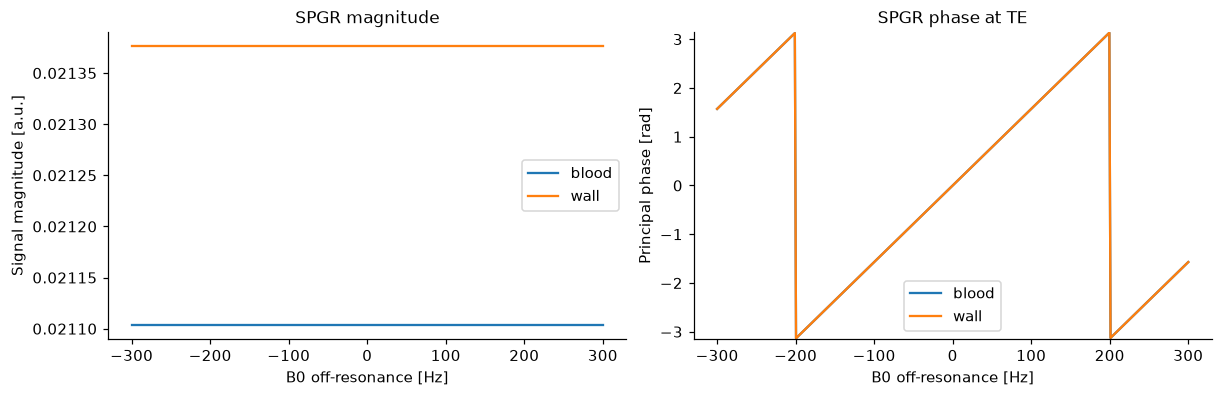

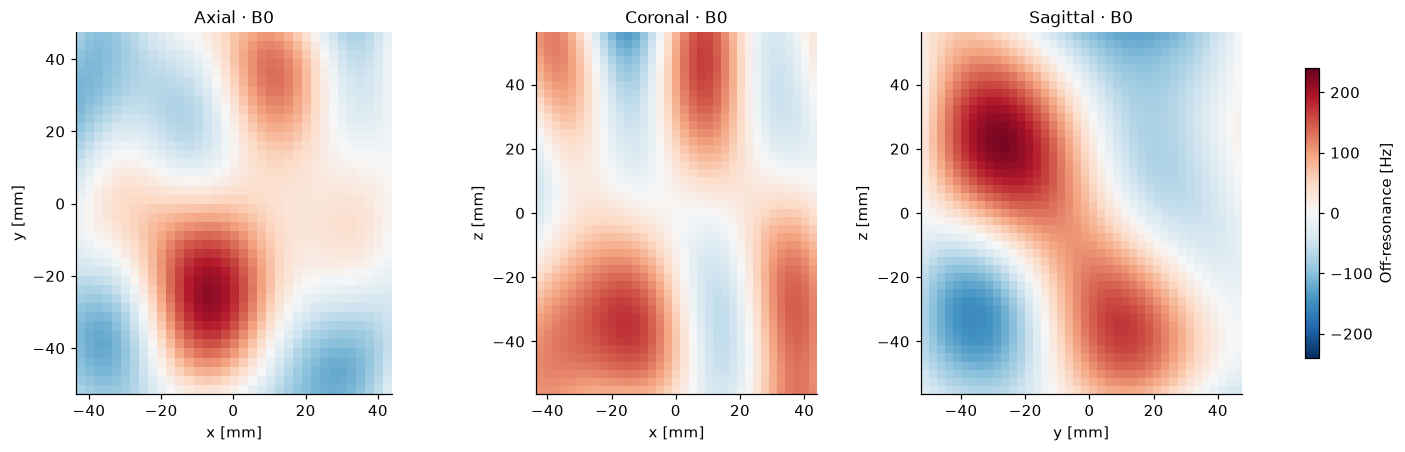

B0 range [Hz]: -227.38433837890625 239.4853057861328


In [18]:
frequencies = np.linspace(-300, 300, 401)
fig, axes = plt.subplots(1,2,figsize=(11,3.5),layout='constrained')
for label, params in [('blood',BLOOD),('wall',WALL)]:
    values = steady_state_signal(Tissue(**params), Sequence(**SEQUENCE), frequencies)
    axes[0].plot(frequencies, abs(values), label=label)
    axes[1].plot(frequencies, np.angle(values), label=label)
axes[0].set(xlabel='B0 off-resonance [Hz]',ylabel='Signal magnitude [a.u.]',title='SPGR magnitude')
axes[1].set(xlabel='B0 off-resonance [Hz]',ylabel='Principal phase [rad]',title='SPGR phase at TE',ylim=(-np.pi,np.pi))
for ax in axes: ax.legend()
save_figure(fig,'02_spgr_signal')
plt.show()

b0_map = np.asarray(result.b0_hz)
b0_limit = max(float(np.max(abs(b0_map))), 1e-6)
fig, axes = plt.subplots(1,3,figsize=(13,4),layout='constrained')
for ax,(name,fixed,shown) in zip(axes,PLANES):
    artist=ax.imshow(plane_view(b0_map,fixed,slice_xyz),origin='lower',
                     extent=plane_extent(image_axes_xyz,shown,resolution),
                     cmap='RdBu_r',vmin=-b0_limit,vmax=b0_limit)
    ax.set_title(f'{name} · B0'); label_plane(ax,shown)
fig.colorbar(artist,ax=axes.tolist(),shrink=0.8,label='Off-resonance [Hz]')
save_figure(fig,'03_b0_orthogonal_planes')
plt.show()
print('B0 range [Hz]:', float(b0_map.min()),float(b0_map.max()))

## 6 · Receive coils

Smooth complex Gaussian sensitivities are normalized so `sum(abs(C)**2)=1` at every location.

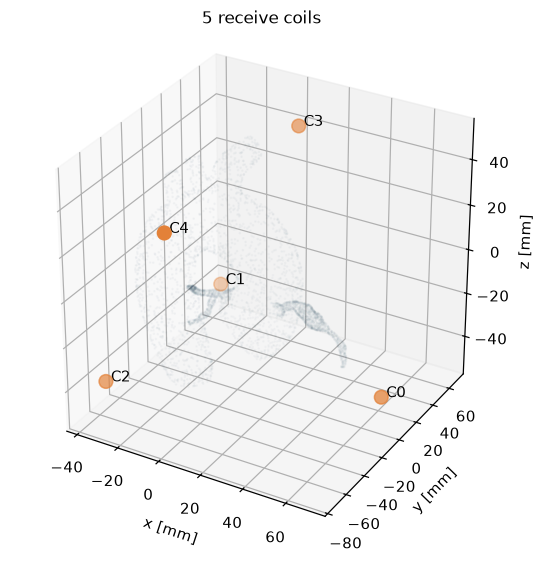

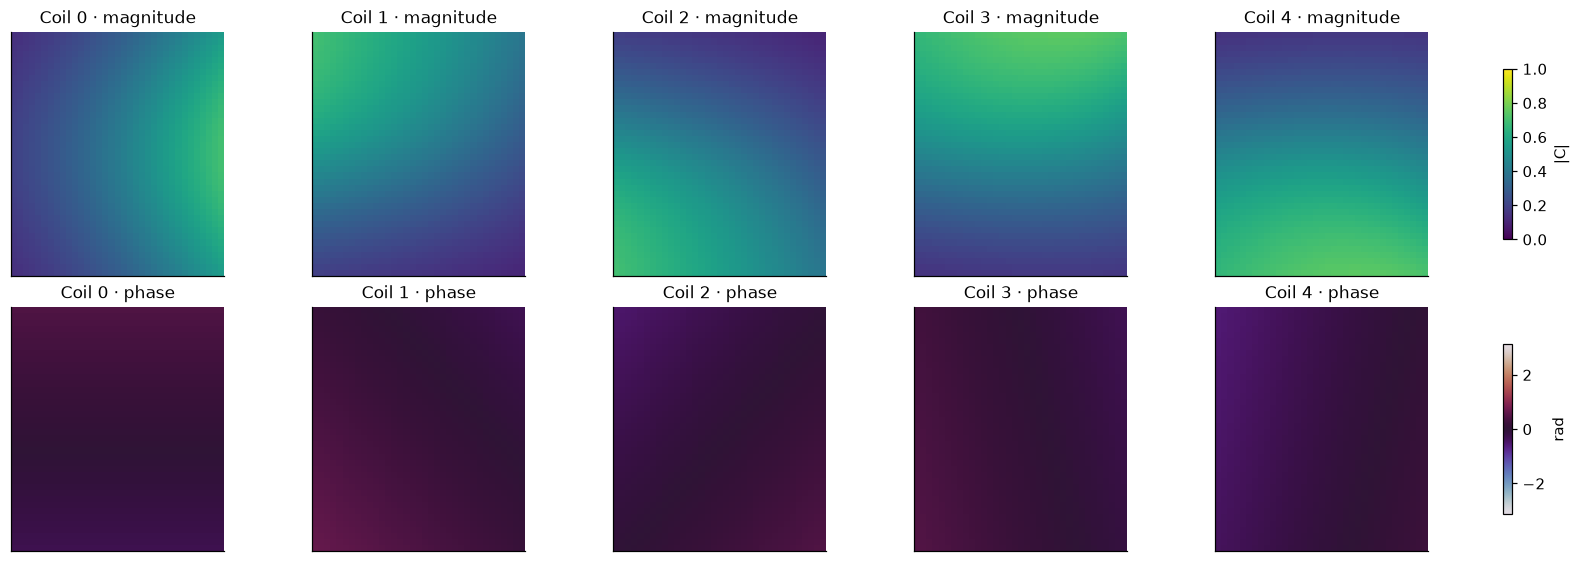

In [19]:
centers = np.asarray(result.metadata['coil_centers_mm'])
fig = plt.figure(figsize=(6,5),layout='constrained')
ax=fig.add_subplot(projection='3d')
indices=case.wall_point_indices[::max(1,len(case.wall_point_indices)//4000)]
ax.scatter(*points[indices].T,s=0.5,alpha=0.2,color='#537286')
ax.scatter(*centers.T,s=80,color='#E38138')
for i,c in enumerate(centers): ax.text(*c,f' C{i}')
ax.set(xlabel='x [mm]',ylabel='y [mm]',zlabel='z [mm]',title=f'{COILS["count"]} receive coils')
ax.set_box_aspect((1,1,1)); save_figure(fig,'04_coil_layout'); plt.show()
fig,axes=plt.subplots(2,COILS['count'],figsize=(3*COILS['count'],5),squeeze=False,layout='constrained')
for c in range(COILS['count']):
    a=axes[0,c].imshow(abs(result.coil_maps[c,slice_xyz[2]]),origin='lower',cmap='viridis',vmin=0,vmax=1)
    b=axes[1,c].imshow(np.angle(result.coil_maps[c,slice_xyz[2]]),origin='lower',cmap='twilight',vmin=-np.pi,vmax=np.pi)
    axes[0,c].set_title(f'Coil {c} · magnitude'); axes[1,c].set_title(f'Coil {c} · phase')
    for row in (0,1): axes[row,c].set(xticks=[],yticks=[])
fig.colorbar(a,ax=axes[0,:].tolist(),shrink=0.7,label='|C|')
fig.colorbar(b,ax=axes[1,:].tolist(),shrink=0.7,label='rad')
save_figure(fig,'05_coil_maps'); plt.show()

## 7 · Reconstruction: all encodings in three orthogonal planes

For the selected frame, each figure shows **reference / vz / vy / vx**, followed by any further VENC channels across columns:

1. Centred **k-space log magnitude for the selected receive coil**, sliced through k=0 in each orientation.
2. **Image magnitude**, reconstructed with a 3D inverse FFT and multi-coil RSS.
3. **Image principal phase**, from sensitivity-weighted complex coil combination, including B0 phase.

Image slices use `VIS_SLICE_XYZ` (or planes containing the most blood). Frequency planes pass through the k-space origin. Velocity is decoded separately in the next cell.
Phase uses complex coil combination with the known synthetic sensitivities, removing their receive phase. Low-SNR phase is masked using `VIS_PHASE_MIN_SNR`; the current B0 field includes a synthetic smooth shim residual.


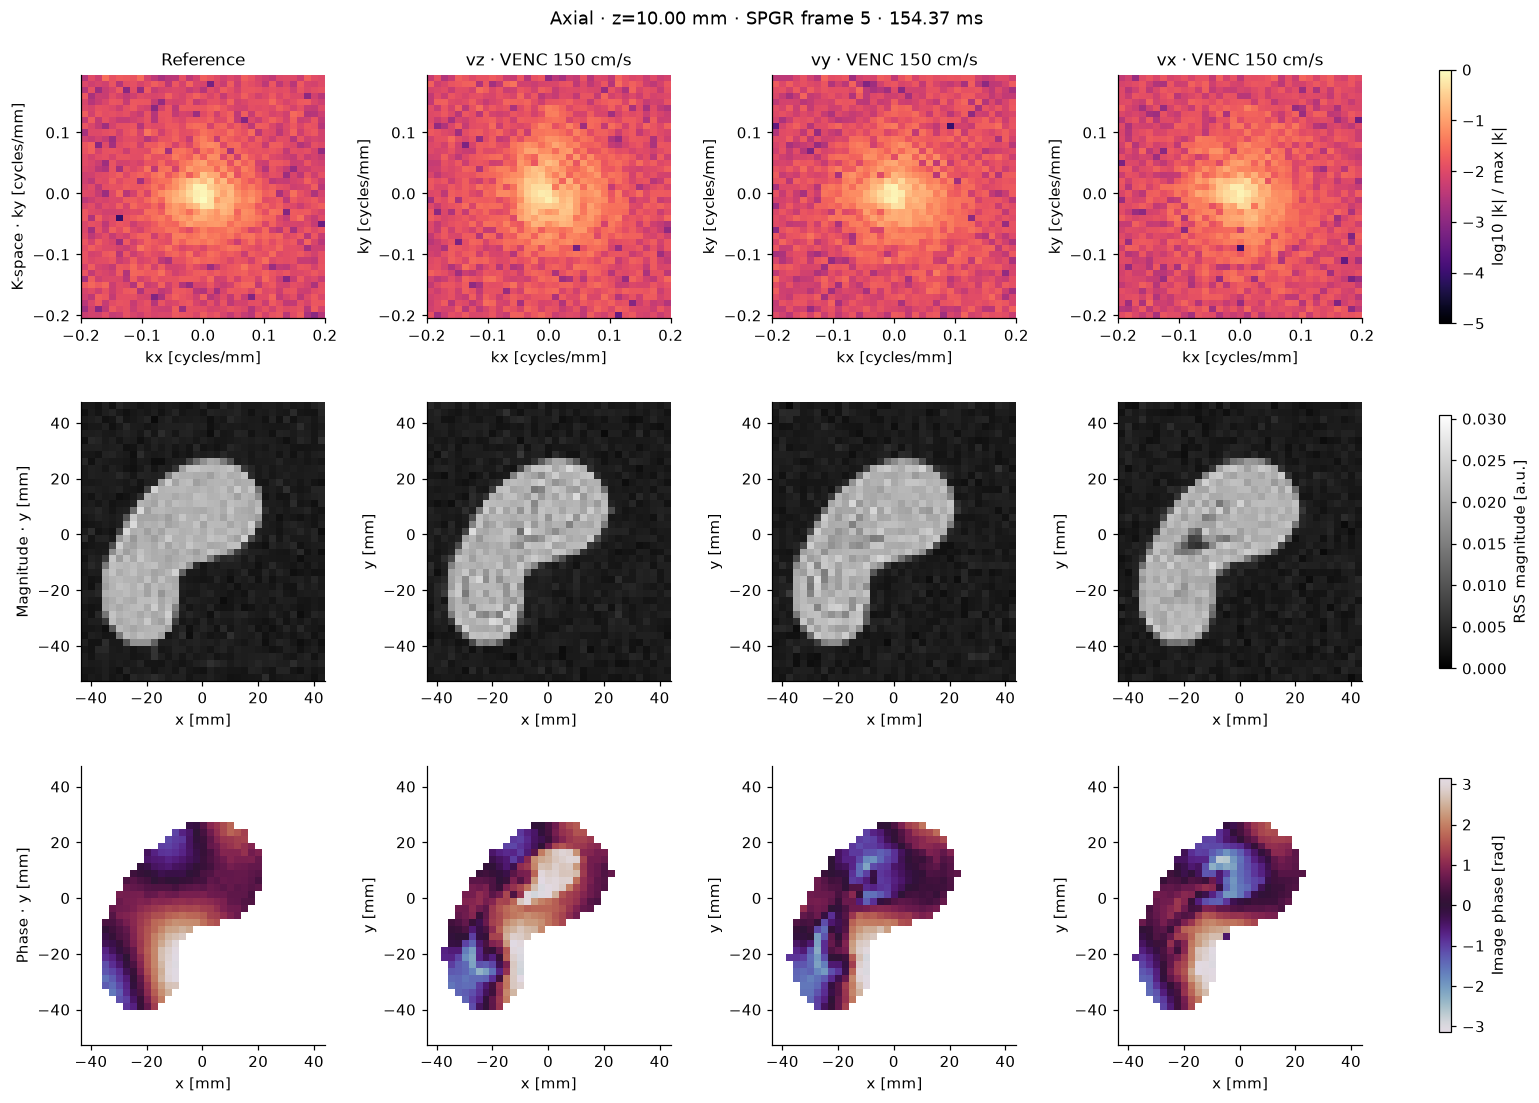

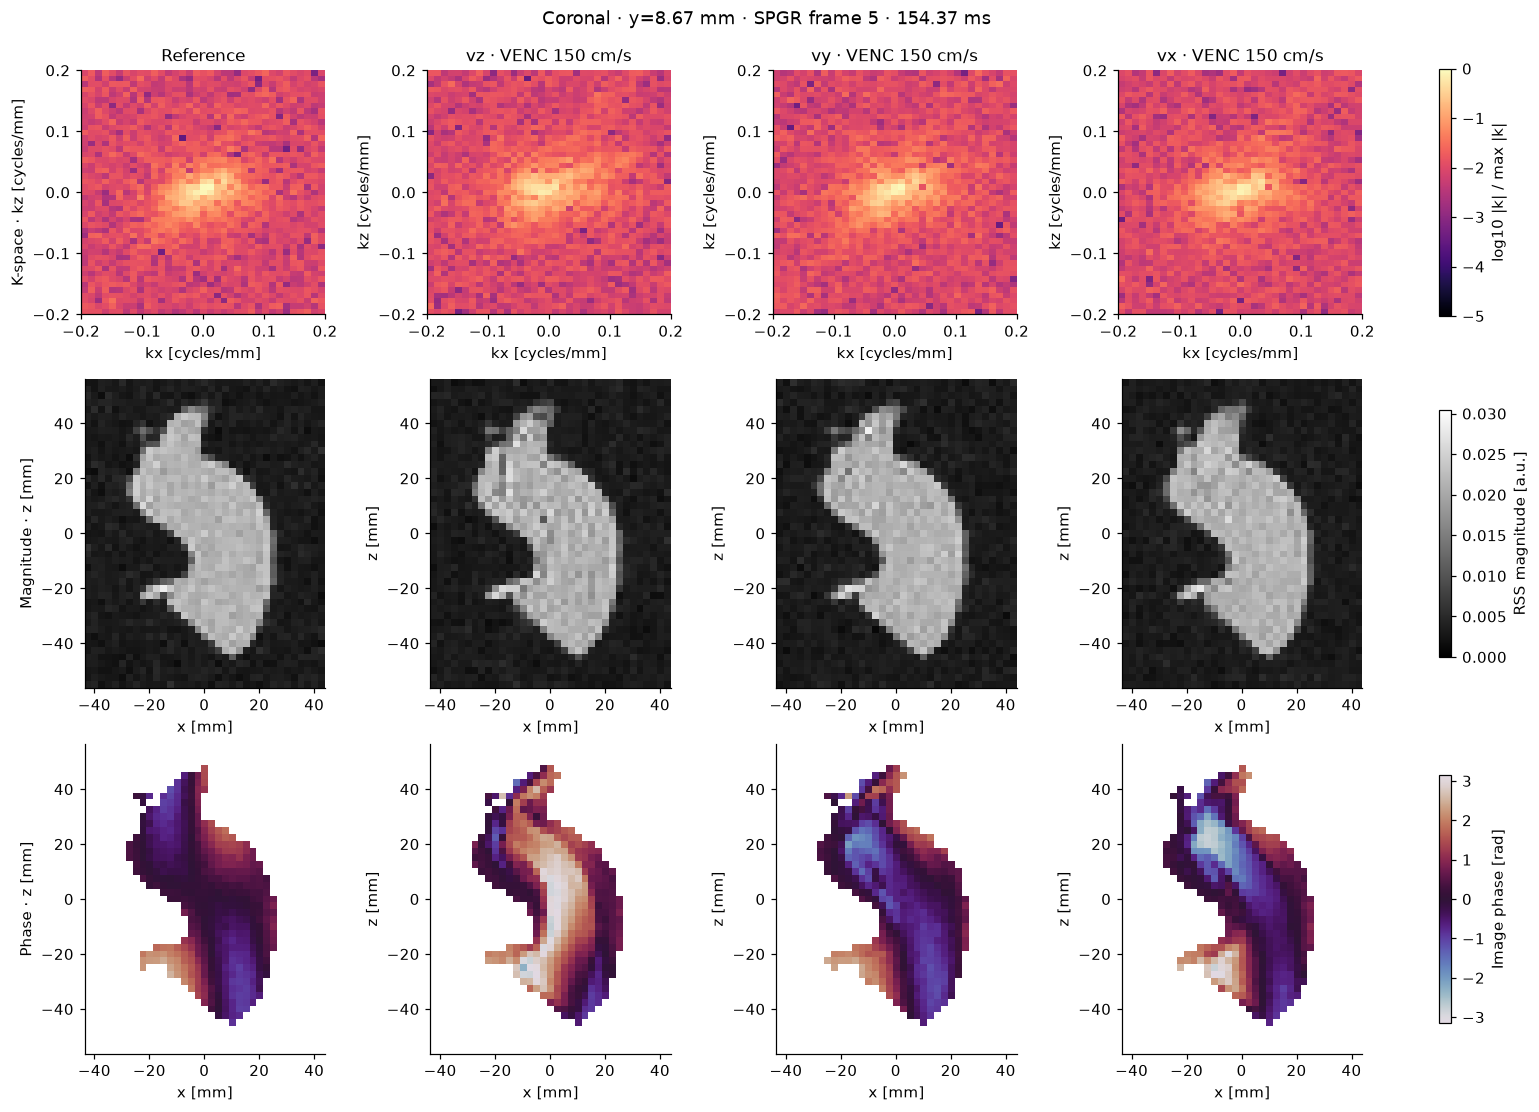

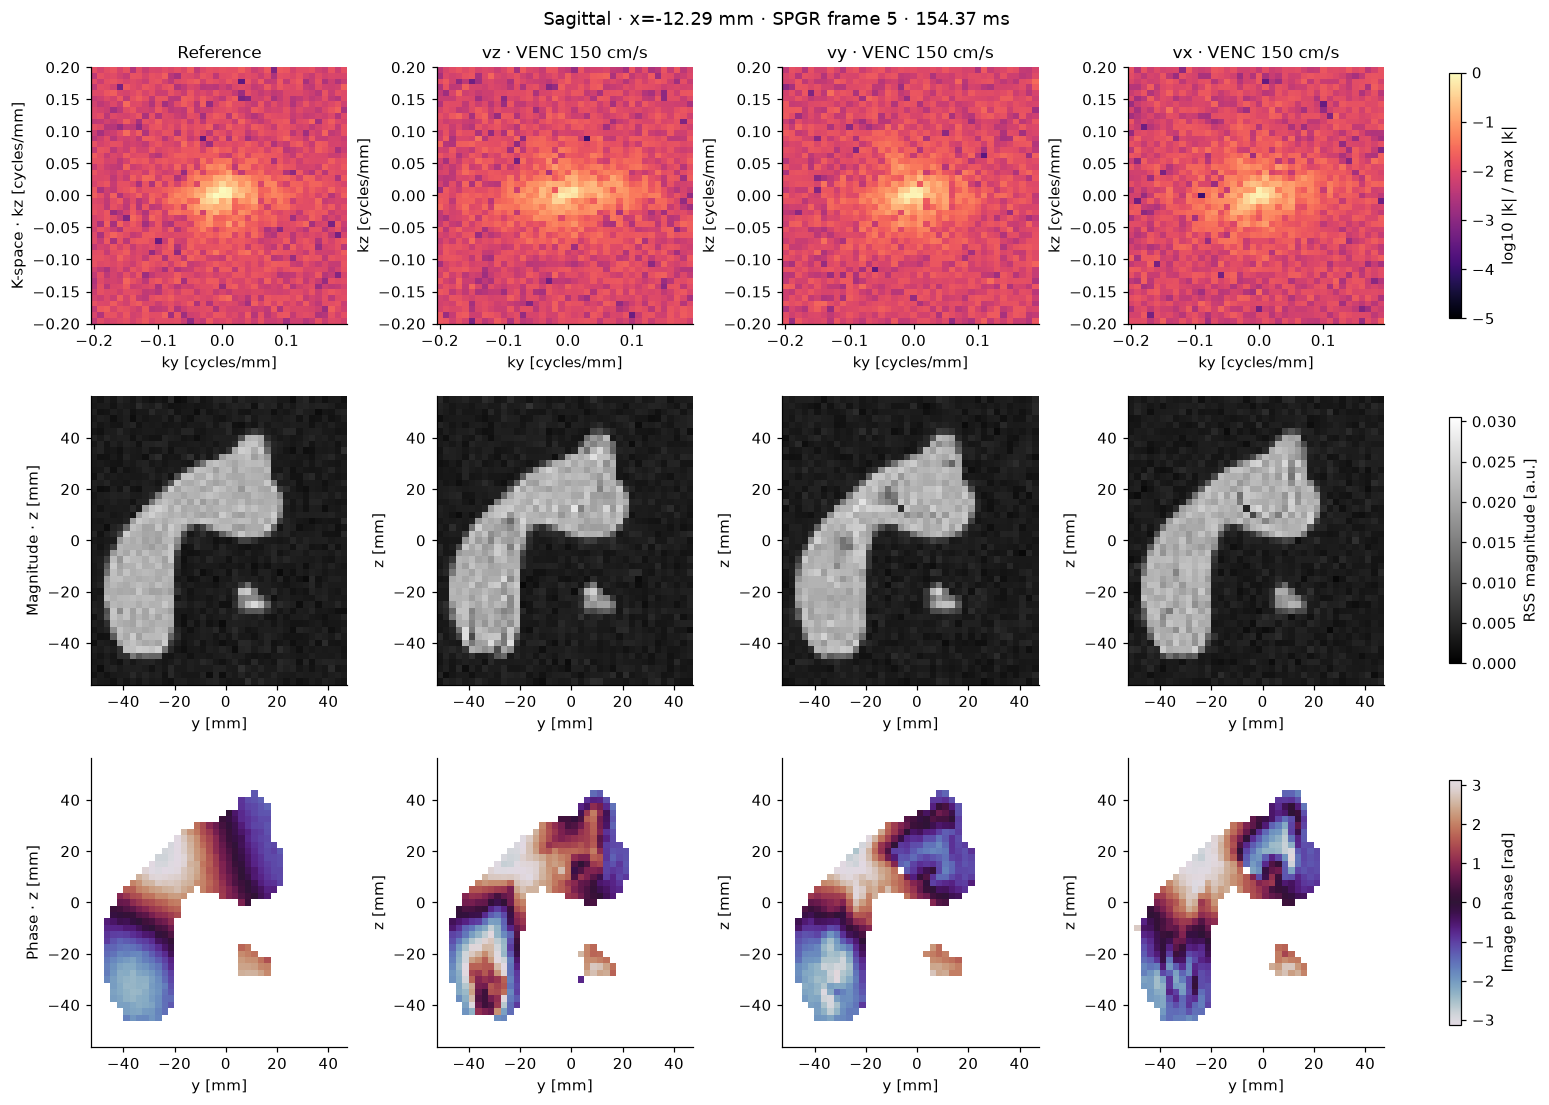

In [20]:
k = np.asarray(result.kspace[:,frame])
if not 0 <= VIS_COIL_INDEX < k.shape[1]:
    raise ValueError('VIS_COIL_INDEX is outside the receive-coil array.')
images = ifft3c(k, device=result.metadata['device'])
combined = np.sum(images*result.coil_maps.conj()[None],axis=1)
magnitude = np.sqrt(np.sum(abs(images)**2,axis=1))
phase = np.angle(combined)
kabs = abs(k[:,VIS_COIL_INDEX])
klog = np.log10(kabs/max(float(kabs.max()),1e-12)+1e-7)
# RSS magnitude has a noise floor; use the complex combined image for phase masking.
if not np.isfinite(VIS_PHASE_MIN_SNR) or VIS_PHASE_MIN_SNR < 0:
    raise ValueError('VIS_PHASE_MIN_SNR must be finite and nonnegative.')
noise_std = result.metadata['noise_std_per_real_imag_component']
combined_magnitude = abs(combined)
phase_threshold = max(VIS_PHASE_MIN_SNR*noise_std, 0.01*float(combined_magnitude.max()))
phase = np.where(combined_magnitude > phase_threshold, phase, np.nan)
encoding_names = ['Reference'] + [f'{axis} · VENC {venc:g} cm/s' for axis,venc in
                                 zip(result.metadata['encoding_order'][1:],result.metadata['venc_cm_s'])]
frequency_slices_xyz = tuple(int(np.argmin(abs(a))) for a in frequency_axes_xyz)
frequency_spacing = 1/(shape_xyz*resolution)
for name,fixed,shown in PLANES:
    fig,axes=plt.subplots(3,len(encoding_names),figsize=(3.5*len(encoding_names),10),squeeze=False,layout='constrained')
    for e,encoding_name in enumerate(encoding_names):
        axes[0,e].set_title(encoding_name)
        a=axes[0,e].imshow(plane_view(klog[e],fixed,frequency_slices_xyz),origin='lower',
                          extent=plane_extent(frequency_axes_xyz,shown,frequency_spacing),
                          cmap='magma',vmin=-5,vmax=0)
        b=axes[1,e].imshow(plane_view(magnitude[e],fixed,slice_xyz),origin='lower',
                          extent=plane_extent(image_axes_xyz,shown,resolution),
                          cmap='gray',vmin=0,vmax=float(magnitude.max()))
        c=axes[2,e].imshow(plane_view(phase[e],fixed,slice_xyz),origin='lower',
                          extent=plane_extent(image_axes_xyz,shown,resolution),
                          cmap='twilight',vmin=-np.pi,vmax=np.pi)
        label_plane(axes[0,e],shown,frequency=True)
        label_plane(axes[1,e],shown); label_plane(axes[2,e],shown)
    axes[0,0].set_ylabel('K-space · '+axes[0,0].get_ylabel())
    axes[1,0].set_ylabel('Magnitude · '+axes[1,0].get_ylabel())
    axes[2,0].set_ylabel('Phase · '+axes[2,0].get_ylabel())
    fig.colorbar(a,ax=axes[0,:].tolist(),shrink=0.8,label='log10 |k| / max |k|')
    fig.colorbar(b,ax=axes[1,:].tolist(),shrink=0.8,label='RSS magnitude [a.u.]')
    fig.colorbar(c,ax=axes[2,:].tolist(),shrink=0.8,label='Image phase [rad]')
    coordinate=image_axes_xyz[fixed][slice_xyz[fixed]]
    fig.suptitle(f'{name} · {"xyz"[fixed]}={coordinate:.2f} mm · SPGR frame {frame} · {result.times_s[frame]*1000:.2f} ms')
    save_figure(fig,f'06_encodings_{name.lower()}'); plt.show()

## 8 · Velocity decoded from encoded/reference phase

For every velocity encoding, `v = angle(S_encoded × conj(S_reference)) × VENC / π`.
This cancels shared B0 phase and returns the **wrapped apparent MRI velocity** in `[-VENC, VENC]` for that channel. Multi-VENC channels retain their individual ranges; no phase unwrapping or cross-VENC fusion is applied. Partial volume and dephasing can also cause differences from CFD truth.

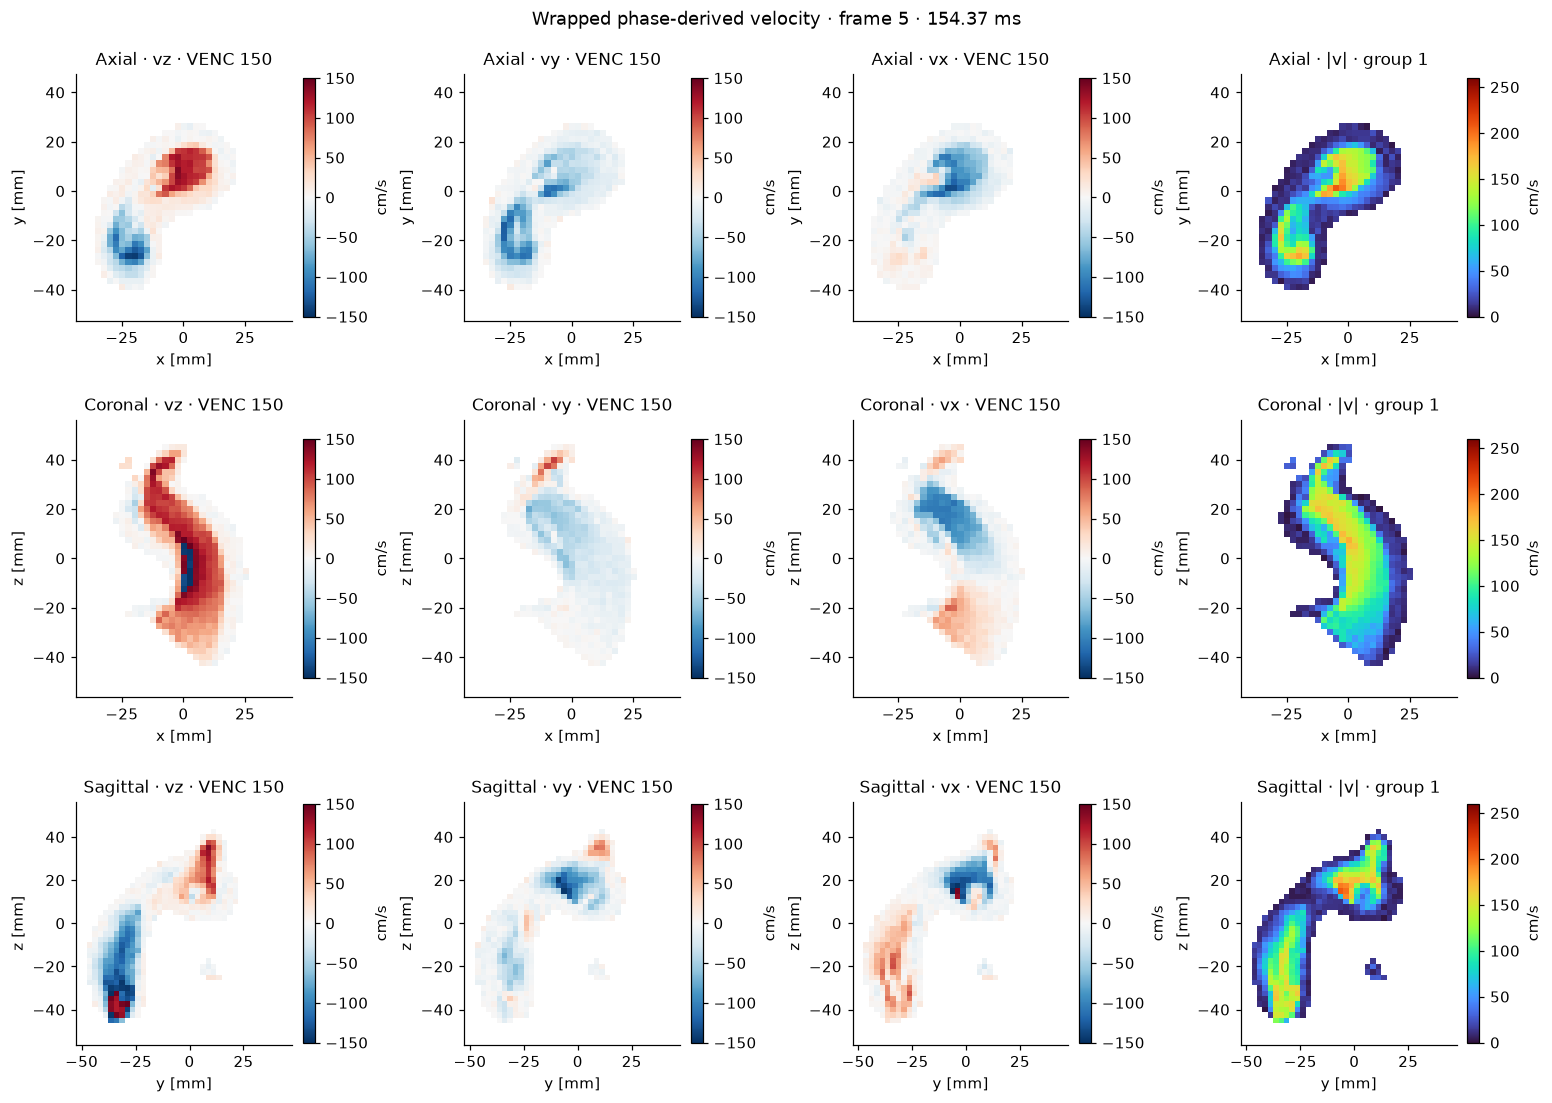

Native CFD peak |vx|/|vy|/|vz| [cm/s]: [240.08 233.37 293.14]
VENC per z/y/x encoding [cm/s]: [150. 150. 150.]


In [21]:
venc_cm_s = np.array(result.metadata['venc_cm_s'])
velocity_phase = np.angle(combined[1:]*combined[0].conj()[None])
velocity_mri_cm_s = velocity_phase*venc_cm_s[:,None,None,None]/np.pi
blood_region = bf > 0.05
velocity_mri_cm_s = np.where(blood_region[None],velocity_mri_cm_s,np.nan)
channel_names = [f'{axis} · VENC {venc:g}' for axis,venc in
                 zip(result.metadata['encoding_order'][1:],venc_cm_s)]
# A speed map requires a complete z/y/x group; partial groups still show their components.
group_speeds = [np.linalg.norm(velocity_mri_cm_s[start:start+3],axis=0)
                for start in range(0,len(venc_cm_s)-2,3)]
fields = list(velocity_mri_cm_s) + group_speeds
labels = channel_names + [f'|v| · group {i+1}' for i in range(len(group_speeds))]
limits = list(venc_cm_s) + [float(np.linalg.norm(venc_cm_s[3*i:3*i+3])) for i in range(len(group_speeds))]
fig,axes=plt.subplots(3,len(fields),figsize=(3.5*len(fields),10),squeeze=False,layout='constrained')
for row,(name,fixed,shown) in enumerate(PLANES):
    for column,(values,label,limit) in enumerate(zip(fields,labels,limits)):
        component = column < len(venc_cm_s)
        artist=axes[row,column].imshow(plane_view(values,fixed,slice_xyz),origin='lower',
                                      extent=plane_extent(image_axes_xyz,shown,resolution),
                                      cmap='RdBu_r' if component else 'turbo',
                                      vmin=-limit if component else 0,vmax=limit)
        axes[row,column].set_title(f'{name} · {label}')
        label_plane(axes[row,column],shown)
        fig.colorbar(artist,ax=axes[row,column],shrink=0.75,label='cm/s')
fig.suptitle(f'Wrapped phase-derived velocity · frame {frame} · {result.times_s[frame]*1000:.2f} ms')
save_figure(fig,'07_decoded_velocity'); plt.show()
print('Native CFD peak |vx|/|vy|/|vz| [cm/s]:',np.round(result.metadata['native_peak_abs_velocity_cm_s_xyz'],2))
print('VENC per z/y/x encoding [cm/s]:',venc_cm_s)

## 9 · Output

`kspace` is complex64 with axes **[V, T, C, Z, Y, X]**. `V` includes the shared reference and each requested velocity encoding.
`OUTPUT=None` returns NumPy arrays without an HDF5 file. A path streams k-space, maps, tissue fractions, CFD truth, timestamps, parameters, sampling decisions, and warnings to HDF5. Figures are saved when `SAVE_FIGURES=True`.

In [22]:
sample=np.asarray(result.kspace[:,frame])
assert sample.dtype==np.complex64 and np.isfinite(sample).all() and np.any(abs(sample)>0)
print('K-space shape [V,T,C,Z,Y,X]:',result.kspace.shape)
print('Time [ms]:',np.round(result.times_s*1000,4))
print('Sampling:',result.metadata['temporal_sampling'])
print('Compute:',result.metadata['compute_backend'],result.metadata['device'])
print('Geometry:',result.metadata['geometry_backend'])
print('Recorded warnings:',result.metadata['warnings'])
print('Target pure-blood SNR:',result.metadata['snr'])
print('Noise std per real/imag component:',result.metadata['noise_std_per_real_imag_component'])
print('HDF5 output:',output)
RESULT.close()

K-space shape [V,T,C,Z,Y,X]: (4, 20, 5, 45, 40, 35)
Time [ms]: [  0.      30.8735  61.747   92.6205 123.494  154.3675 185.241  216.1145
 246.988  277.8615 308.735  339.6085 370.482  401.3555 432.229  463.1025
 493.976  524.8495 555.723  586.5965]
Sampling: native
Compute: cupy-cuda cuda:0
Geometry: vtk-cpu-volume+warp-cuda-wall
Recorded warnings: ['Native CFD velocity exceeds VENC (vz: 293.14 > 150 cm/s; vy: 233.37 > 150 cm/s; vx: 240.08 > 150 cm/s). Complex phase encoding is retained without velocity clipping; decoded principal phase wraps into [-VENC, VENC].']
Target pure-blood SNR: 20.0
Noise std per real/imag component: 0.0010551955740699085
HDF5 output: None
